# PGD-L∞ атака на ResNet18, обученный на CIFAR-10

Структура DataModule/LightningModule соответствует `code_templates/lightning_template.ipynb`.

In [1]:
!pip install lightning -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 16.4 MB/s eta 0:00:00a 0:00:01


In [3]:
from pathlib import Path
import csv
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import lightning as L

SEED = 42
L.seed_everything(SEED)
CKPT_PATH = Path('/kaggle/input/models/slomauh/resnet-18-cifar10/pytorch/default/1/resnet18_cifar10_best.pth')
CIFAR_INPUT_PATH = Path('/kaggle/input/datasets/oxcdcd/cifar10/cifar10')
DOWNLOAD_ROOT = Path('/kaggle/working/data')
OUTPUT_DIR = Path('/kaggle/working/pgd_results')
BATCH_SIZE, NUM_WORKERS = 256, 2
EPSILON_NUMERATORS = [0, 2, 4]
PGD_STEPS = 10
EXAMPLES_TO_SHOW = 8
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Device:', DEVICE)

Seed set to 42


Device: cuda


# Загрузка CIFAR-10, DataModule

In [4]:
CIFAR10_CLASSES = ('airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck')

class CIFAR10DataModule(L.LightningDataModule):
    def __init__(self, input_path, download_root, batch_size=256, num_workers=2):
        super().__init__()
        self.input_path = Path(input_path)
        self.download_root = Path(download_root)
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.transform = transforms.ToTensor()

    @property
    def imagefolder_test(self):
        return self.input_path / 'test'

    def prepare_data(self):
        if self.imagefolder_test.is_dir():
            return
        self.download_root.mkdir(parents=True, exist_ok=True)
        print('Локальный test/ не найден; CIFAR-10 скачивается из интернета.')
        datasets.CIFAR10(self.download_root, train=False, download=True)

    def setup(self, stage=None):
        if self.imagefolder_test.is_dir():
            self.test_set = datasets.ImageFolder(self.imagefolder_test, transform=self.transform)
            folder_classes = tuple(self.test_set.classes)
            numeric_classes = tuple(str(index) for index in range(10))
            if folder_classes not in (CIFAR10_CLASSES, numeric_classes):
                raise ValueError(f'Неожиданные классы ImageFolder: {folder_classes}')
            print('CIFAR-10 загружен из:', self.imagefolder_test)
        else:
            self.test_set = datasets.CIFAR10(
                self.download_root, train=False, download=False, transform=self.transform
            )

    def test_dataloader(self):
        return DataLoader(self.test_set, batch_size=self.batch_size, shuffle=False,
            num_workers=self.num_workers, pin_memory=True,
            persistent_workers=self.num_workers > 0, drop_last=False)

dm = CIFAR10DataModule(CIFAR_INPUT_PATH, DOWNLOAD_ROOT, BATCH_SIZE, NUM_WORKERS)
dm.prepare_data(); dm.setup()
sample_x, sample_y = next(iter(dm.test_dataloader()))
assert tuple(sample_x.shape[1:]) == (3,32,32)
assert sample_x.min().item() >= 0 and sample_x.max().item() <= 1
print(f'Test images: {len(dm.test_set):,}; batch: {tuple(sample_x.shape)}')

Локальный test/ не найден; CIFAR-10 скачивается из интернета.


100%|██████████| 170M/170M [17:58<00:00, 158kB/s] 


Test images: 10,000; batch: (256, 3, 32, 32)


# LightningModule и загрузка весов

In [5]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer('mean',torch.tensor(mean).view(1,-1,1,1))
        self.register_buffer('std',torch.tensor(std).view(1,-1,1,1))
    def forward(self,x): return (x-self.mean)/self.std

class NormalizedModel(nn.Module):
    def __init__(self,model,mean,std):
        super().__init__(); self.normalize=Normalize(mean,std); self.model=model
    def forward(self,x): return self.model(self.normalize(x))

class CIFAR10Classifier(L.LightningModule):
    def __init__(self,num_classes=10,mean=(0.4914,0.4822,0.4465),std=(0.2470,0.2435,0.2616)):
        super().__init__(); self.save_hyperparameters()
        raw_model=models.resnet18(weights=None,num_classes=num_classes)
        raw_model.conv1=nn.Conv2d(3,64,3,stride=1,padding=1,bias=False)
        raw_model.maxpool=nn.Identity()
        self.model=NormalizedModel(raw_model,mean,std)
    def forward(self,x): return self.model(x)
    def test_step(self,batch,batch_idx):
        x,y=batch; logits=self(x); acc=(logits.argmax(1)==y).float().mean()
        self.log('test_acc',acc,on_epoch=True,sync_dist=True,batch_size=y.size(0))

def load_weights(lightning_model,path):
    if not path.is_file(): raise FileNotFoundError(f'Не найдены веса: {path}')
    checkpoint=torch.load(path,map_location='cpu',weights_only=True)
    state=checkpoint.get('state_dict',checkpoint)
    converted={}
    for key,value in state.items():
        key=key.removeprefix('module.')
        if key.startswith('normalize.'): continue
        key=key.replace('linear.','fc.').replace('.shortcut.','.downsample.')
        converted[key]=value
    lightning_model.model.model.load_state_dict(converted,strict=True)
    return checkpoint

model=CIFAR10Classifier()
checkpoint=load_weights(model,CKPT_PATH)
epoch=checkpoint.get('epoch','unknown'); val_acc=checkpoint.get('val_acc')
print('Weights:',CKPT_PATH,'| epoch:',epoch,'| val_acc:',val_acc)

Weights: /kaggle/input/models/slomauh/resnet-18-cifar10/pytorch/default/1/resnet18_cifar10_best.pth | epoch: 29 | val_acc: 0.932


# Smoke-тест

In [6]:
smoke_trainer=L.Trainer(fast_dev_run=True,accelerator='auto',devices=1,
    logger=False,enable_checkpointing=False)
smoke_trainer.test(model,datamodule=dm)
print('Lightning smoke-тест пройден')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Running in `fast_dev_run` mode: will run the requested loop using 1 batch(es). Logging and checkpointing is suppressed.


Локальный test/ не найден; CIFAR-10 скачивается из интернета.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │        0.94140625         │
└───────────────────────────┴───────────────────────────┘

Lightning smoke-тест пройден


# PGD-L∞

In [7]:
def pgd_linf(net,x,y,epsilon,steps=10):
    original=x.detach()
    if epsilon==0: return original.clone()
    x_adv=(original+torch.empty_like(original).uniform_(-epsilon,epsilon)).clamp(0,1)
    for _ in range(steps):
        x_adv.requires_grad_(True)
        gradient=torch.autograd.grad(F.cross_entropy(net(x_adv),y),x_adv)[0]
        with torch.no_grad():
            x_adv=x_adv+(epsilon/4)*gradient.sign()
            x_adv=(original+(x_adv-original).clamp(-epsilon,epsilon)).clamp(0,1)
    return x_adv.detach()

model=model.to(DEVICE).eval().requires_grad_(False)
smoke_x,smoke_y=sample_x[:7].to(DEVICE),sample_y[:7].to(DEVICE)
smoke_epsilon=4/255
smoke_adv=pgd_linf(model,smoke_x,smoke_y,smoke_epsilon,PGD_STEPS)
assert smoke_adv.min().item()>=0 and smoke_adv.max().item()<=1
assert (smoke_adv-smoke_x).abs().max().item()<=smoke_epsilon+1e-6
assert torch.equal(pgd_linf(model,smoke_x,smoke_y,0,PGD_STEPS),smoke_x)
assert all(parameter.grad is None for parameter in model.parameters())
print('PGD smoke-тест пройден')

PGD smoke-тест пройден


# Оценка устойчивости

In [8]:
def evaluate_attack(net,loader,epsilon,steps,collect_examples=0):
    total=clean_correct=robust_correct=successful=0; examples=[]; max_delta=0.0
    for x,y in loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        with torch.no_grad(): clean_pred=net(x).argmax(1)
        with torch.enable_grad(): x_adv=pgd_linf(net,x,y,epsilon,steps)
        with torch.no_grad(): adv_pred=net(x_adv).argmax(1)
        clean_mask=clean_pred.eq(y); robust_mask=adv_pred.eq(y); success_mask=clean_mask & ~robust_mask
        total+=y.size(0); clean_correct+=clean_mask.sum().item(); robust_correct+=robust_mask.sum().item()
        successful+=success_mask.sum().item(); max_delta=max(max_delta,(x_adv-x).abs().max().item())
        if len(examples)<collect_examples:
            for index in success_mask.nonzero(as_tuple=False).flatten().tolist():
                examples.append({'clean':x[index].cpu(),'adversarial':x_adv[index].cpu(),
                    'label':y[index].item(),'clean_prediction':clean_pred[index].item(),
                    'adversarial_prediction':adv_pred[index].item()})
                if len(examples)==collect_examples: break
    assert max_delta<=epsilon+1e-6
    return {'clean_accuracy':clean_correct/total,'robust_accuracy':robust_correct/total,
        'attack_success_rate':successful/clean_correct if clean_correct else 0.0,
        'max_linf':max_delta,'examples':examples}

results=[]; examples_at_max=[]; test_loader=dm.test_dataloader()
for eps_num in EPSILON_NUMERATORS:
    epsilon=eps_num/255; started=time.time()
    metrics=evaluate_attack(model,test_loader,epsilon,PGD_STEPS,
        EXAMPLES_TO_SHOW if eps_num==max(EPSILON_NUMERATORS) else 0)
    elapsed=time.time()-started
    results.append({'epsilon_numerator':eps_num,'epsilon':epsilon,'steps':PGD_STEPS,
        'alpha':epsilon/4 if epsilon else 0.0,'clean_accuracy':metrics['clean_accuracy'],
        'robust_accuracy':metrics['robust_accuracy'],
        'attack_success_rate':metrics['attack_success_rate'],
        'max_linf':metrics['max_linf'],'elapsed_seconds':elapsed})
    if eps_num==max(EPSILON_NUMERATORS): examples_at_max=metrics['examples']
    print(f'ε={eps_num}/255 | robust={metrics["robust_accuracy"]*100:.2f}% | '
          f'success={metrics["attack_success_rate"]*100:.2f}% | {elapsed:.1f}s')

ε=0/255 | robust=93.30% | success=0.00% | 4.2s
ε=2/255 | robust=5.12% | success=94.51% | 53.6s
ε=4/255 | robust=0.11% | success=99.88% | 59.1s


# Графики и примеры

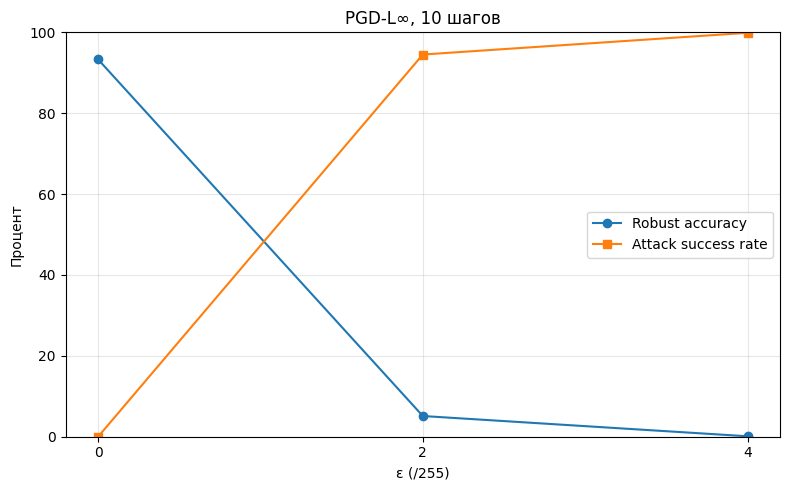

In [9]:
eps=[row['epsilon_numerator'] for row in results]
fig,axis=plt.subplots(figsize=(8,5))
axis.plot(eps,[row['robust_accuracy']*100 for row in results],marker='o',label='Robust accuracy')
axis.plot(eps,[row['attack_success_rate']*100 for row in results],marker='s',label='Attack success rate')
axis.set(xlabel='ε (/255)',ylabel='Процент',title=f'PGD-L∞, {PGD_STEPS} шагов',xticks=eps,ylim=(0,100))
axis.grid(alpha=.3); axis.legend(); fig.tight_layout()
fig.savefig(OUTPUT_DIR/'pgd_robustness_curve.png',dpi=160); plt.show()

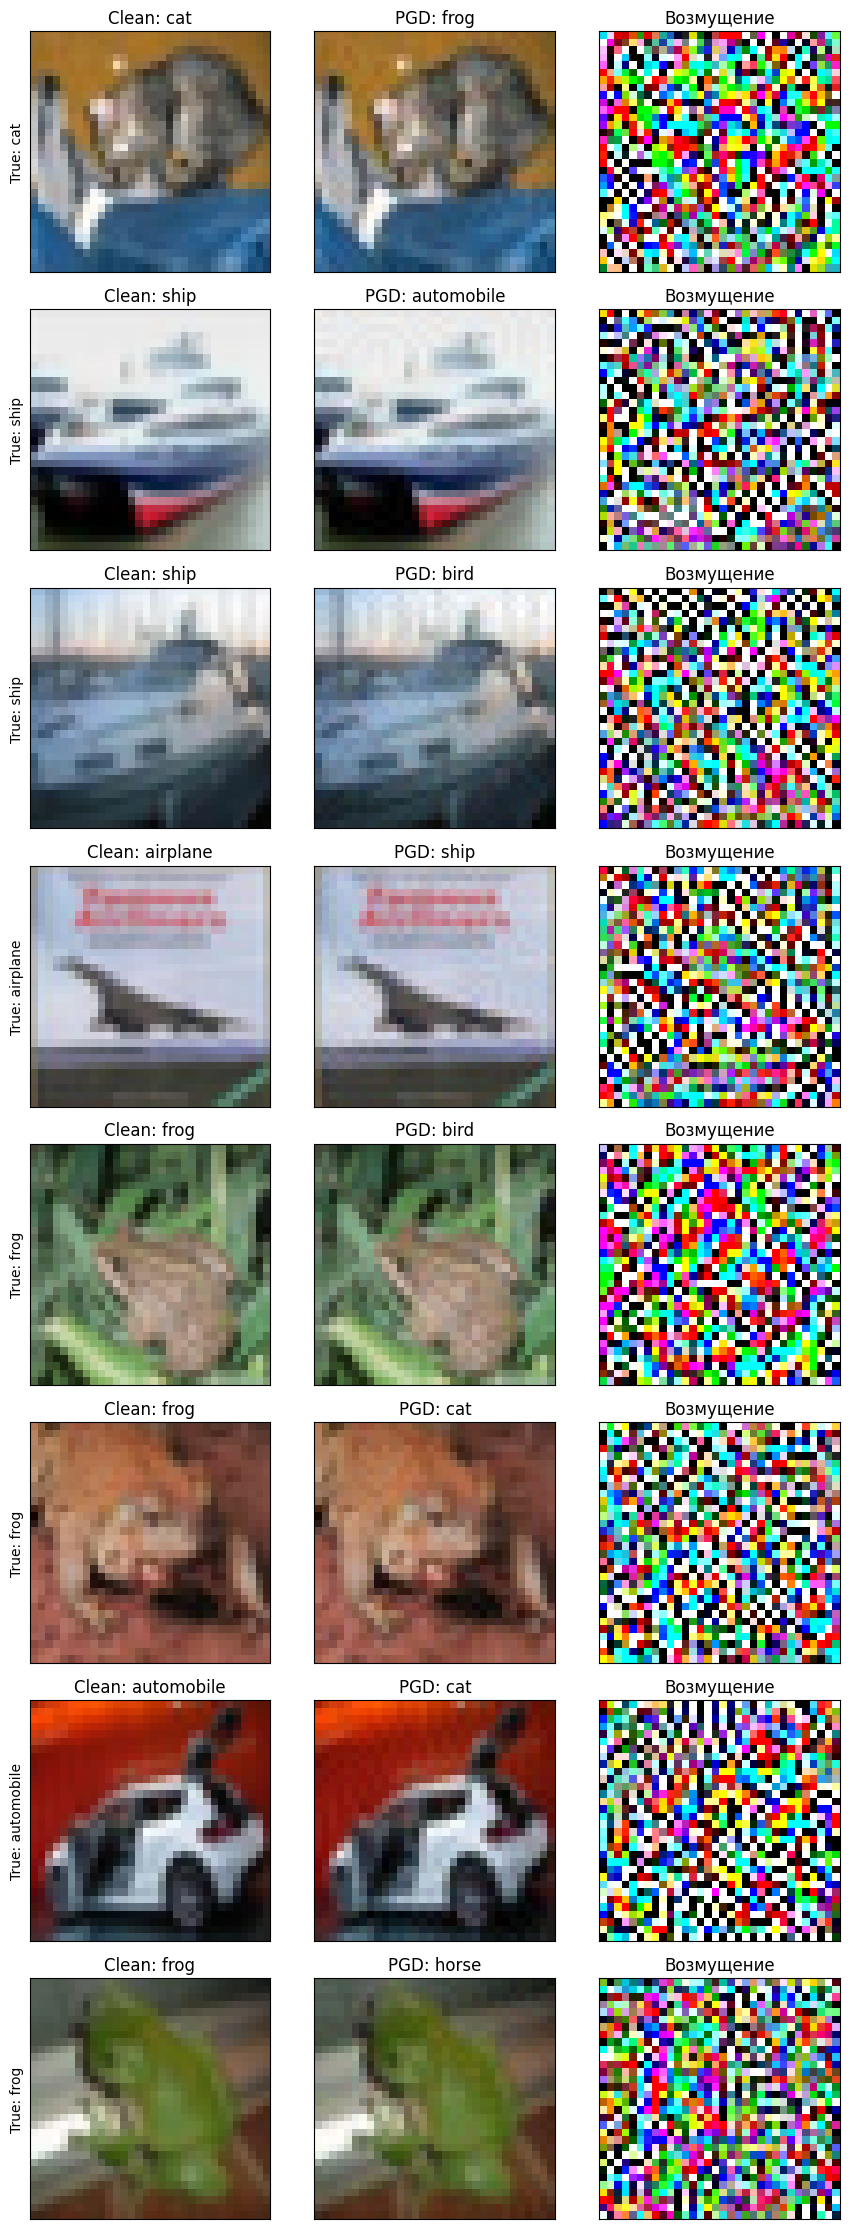

In [12]:
if examples_at_max:
    rows=len(examples_at_max); fig,axes=plt.subplots(rows,3,figsize=(9,2.8*rows),squeeze=False)
    epsilon_max=max(EPSILON_NUMERATORS)/255
    for row,example in enumerate(examples_at_max):
        clean=example['clean'].permute(1,2,0).numpy(); adv=example['adversarial'].permute(1,2,0).numpy()
        perturbation=(adv-clean)/(2*epsilon_max)+.5
        axes[row,0].imshow(clean); axes[row,0].set_title(f'Clean: {CIFAR10_CLASSES[example["clean_prediction"]]}')
        axes[row,1].imshow(adv); axes[row,1].set_title(f'PGD: {CIFAR10_CLASSES[example["adversarial_prediction"]]}')
        axes[row,2].imshow(np.clip(perturbation,0,1)); axes[row,2].set_title('Возмущение')
        axes[row,0].set_ylabel(f'True: {CIFAR10_CLASSES[example["label"]]}')
        for ax in axes[row]: ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout(); fig.savefig(OUTPUT_DIR/'pgd_examples.png',dpi=160,bbox_inches='tight'); plt.show()

# Сохранение результатов

In [11]:
with (OUTPUT_DIR/'pgd_metrics.csv').open('w',newline='',encoding='utf-8') as file:
    writer=csv.DictWriter(file,fieldnames=results[0].keys()); writer.writeheader(); writer.writerows(results)
with (OUTPUT_DIR/'pgd_metrics.json').open('w',encoding='utf-8') as file:
    json.dump(results,file,indent=2,ensure_ascii=False)
print('Kaggle Output:'); [print(' ',path) for path in sorted(OUTPUT_DIR.iterdir())]

Kaggle Output:
  /kaggle/working/pgd_results/pgd_examples.png
  /kaggle/working/pgd_results/pgd_metrics.csv
  /kaggle/working/pgd_results/pgd_metrics.json
  /kaggle/working/pgd_results/pgd_robustness_curve.png


[None, None, None, None]